# Active Experimental Design under Noise and Budget Constraints

In many experiments we aim to discover how a property depends on composition or processing conditions. This is often a case for characterization by XRD, SPM, Raman etc. of spread combinatorial libraries, where a continuous range of compositions is explored on a single substrate.

A mainstream approach for automating such experiments is Bayesian optimization (BO), where a surrogate model (e.g. Gaussian process) is used to predict the property and guide the selection of the next measurement in an active, closed-loop manner.

However, classical BO typically assumes idealized conditions and does not explicitly account for key experimental constraints, such as:

- measurement noise that depends on acquisition time,
- limited experimental budget,
- and cost of moving between measurement locations.

In this challenge, the goal is to design a strategy that, using a surrogate model, decides:

- **where to measure**,
- **in what order**,
- and **for how long**,

in order to efficiently explore and recover the underlying functional dependence under these realistic conditions.

###gif_Classical BO with GP surrogate model



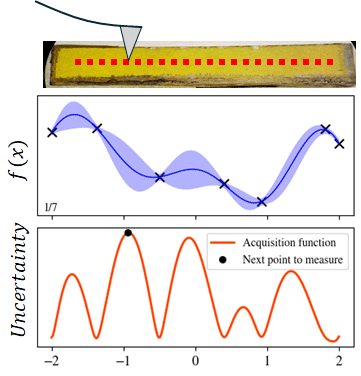

## Functions

In [27]:
!pip install gpytorch

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

In [29]:
#@title target function

# F1 — Smooth unimodal
def unimodal(x):
    x = np.asarray(x)
    res = 0.15 * (x + 2)**2 + 0.03 * (x - 1)**4
    return res


# F2 — Double-well
def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 4)**2 + 0.15 * x
    return res


# F3 — Multimodal (Rastrigin-like, 1D)
def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    return res


# F4 — Broad + narrow minima
def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x + 1.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.18**2))
    )
    return res

In [30]:
#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [31]:
#@title heteroskedastic_noise_model

def make_heteroskedastic_noise_model(f, xlim, n_grid=200, smooth_window=3):
    """
    Build heteroskedastic noise model on a fixed domain.

    Parameters
    ----------
    f : callable
        Ground truth function
    xlim : tuple (xmin, xmax)
        Domain of interest
    """

    xmin, xmax = xlim
    x_grid = np.linspace(xmin, xmax, n_grid)
    y_grid = f(x_grid)

    # gradient
    grad = np.abs(np.gradient(y_grid, x_grid, edge_order=2))

    # smoothing
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        half = smooth_window // 2
        grad_s = np.pad(grad, pad_width=half, mode="reflect")
        grad = np.convolve(grad_s, kernel, mode="valid")

    # normalization
    scale = np.percentile(grad, 95) + 1e-12
    grad_norm_grid = grad / scale

    def noise_model(x, t, sigma_min=0.05, sigma_max=0.5, tau=1.5):
        x = np.asarray(x, dtype=float)
        t = np.asarray(t, dtype=float)

        g = np.interp(x, x_grid, grad_norm_grid)
        sigma0_x = sigma_min + (sigma_max - sigma_min) * g

        return sigma_min + (sigma0_x - sigma_min) * np.exp(-t / tau)

    return noise_model

In [32]:
#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

In [33]:
#@title gp functions

import torch
import gpytorch


def gp_predict(x_train, y_train, x_test, training_iter=100, lr=0.1):
    """
    Fit GP on (x_train, y_train) and predict on x_test.

    Parameters
    ----------
    x_train : array-like (N,)
    y_train : array-like (N,)
    x_test  : array-like (M,)

    Returns
    -------
    mean : (M,)
    std  : (M,)
    """

    # convert to torch
    x_train = torch.as_tensor(x_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)
    x_test  = torch.as_tensor(x_test, dtype=torch.float32)

    # ensure 2D inputs
    if x_train.ndim == 1:
        x_train = x_train.unsqueeze(-1)
    if x_test.ndim == 1:
        x_test = x_test.unsqueeze(-1)

    # define model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()

    class GPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super().__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel()
            )

        def forward(self, x):
            mean = self.mean_module(x)
            covar = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean, covar)

    model = GPModel(x_train, y_train, likelihood)

    # train
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for _ in range(training_iter):
        optimizer.zero_grad()
        output = model(x_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()

    # predict
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        pred = likelihood(model(x_test))
        mean = pred.mean.cpu().numpy()
        std = pred.stddev.cpu().numpy()

    return mean, std

In [34]:
#@title cost models

def travel_cost(dx, speed=0.5) -> float:
  return abs(dx) / speed


## Introduction

In [35]:
x = np.linspace(-4,4,100) #spatial coordinate (compositional/parameter space)
t = np.linspace(0,10,100) #acquisition time

We suggest selecting one of the following four “ground truth” functions to represent the underlying functionality.

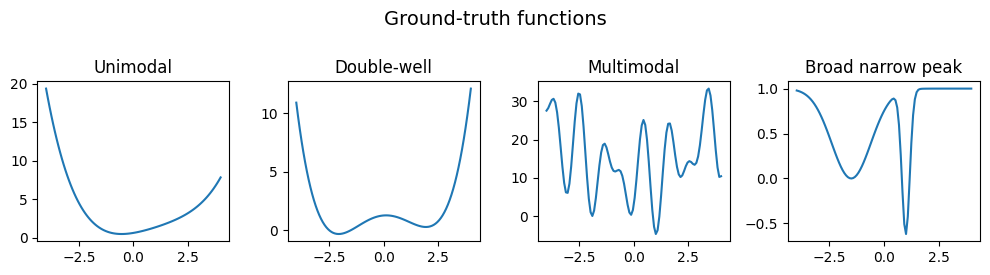

In [36]:
#ground truth functions
fig, ax = plt.subplots(1,4, figsize=(10, 2.7))

ax[0].plot(x, unimodal(x))
ax[1].plot(x, double_well(x))
ax[2].plot(x, multimodal(x))
ax[3].plot(x, broad_narrow(x))

ax[0].set_title('Unimodal')
ax[1].set_title('Double-well')
ax[2].set_title('Multimodal')
ax[3].set_title('Broad narrow peak')

fig.suptitle('Ground-truth functions', y=1, fontsize=14)

plt.tight_layout()

To emulate noisy measurements, we consider two homoscedastic noise models. The first is a **constant noise** model (trivial case), where the measurement precision is independent of acquisition time. The second is a **decaying noise** model, where the noise decreases exponentially with acquisition time and approaches a maximum achievable precision.

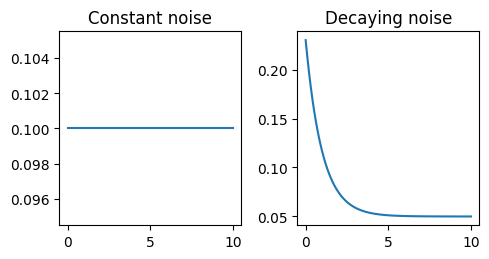

In [37]:
#homoskedastic noise model

fig, ax = plt.subplots(1,2, figsize=(5, 2.7))

ax[0].plot(t, noise_constant(x, t))
ax[0].set_title('Constant noise')
ax[1].plot(t, noise_decay_floor(x, t))
ax[1].set_title('Decaying noise')

plt.tight_layout()

For those seeking more hardcore challenge, we also suggest a **heteroscedastic noise model**, where the measurement noise depends on the location. In our specific case, the noise level is proportional to the local gradient of the underlying function, while still decaying with acquisition time toward a limiting precision.

Text(0.5, 0.98, 'Heteroskedastic noise model')

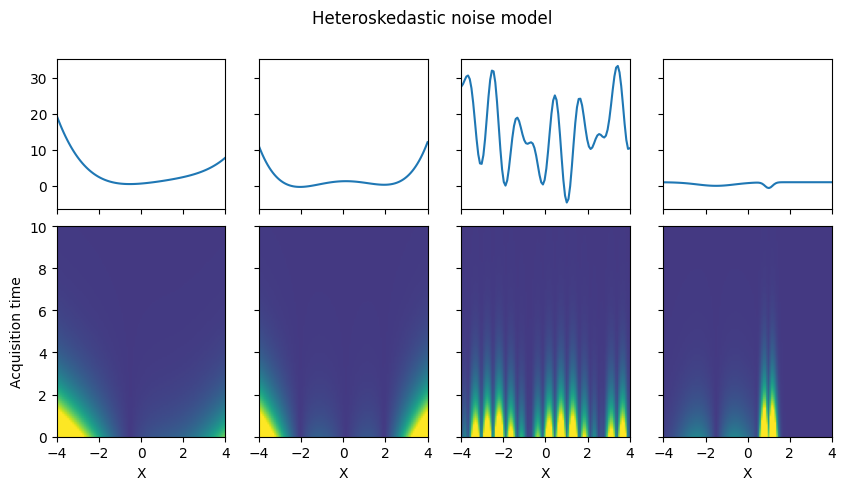

In [38]:
#@title heteroskedastic noise model

funcs = [unimodal, double_well, multimodal, broad_narrow]

fig, ax = plt.subplots(2, 4, figsize=(10, 5),
                       height_ratios=(1,1.5),
                       sharex=True,
                       sharey='row',
                       gridspec_kw={'hspace': 0.05})

for i,ax0_ in enumerate(ax[0]):
  ax0_.plot(x, funcs[i](x))

for i,ax1_ in enumerate(ax[1]):
  noise_model = make_heteroskedastic_noise_model(funcs[i], (-4, 4))
  ax1_.imshow(noise_model(x, t.reshape(-1,1)),
              origin='lower',
              extent=[x.min(), x.max(), t.min(), t.max()],
              vmax=.3, vmin=0)
  ax1_.set_xlabel('X')

ax[1,0].set_ylabel('Acquisition time')

fig.suptitle('Heteroskedastic noise model')


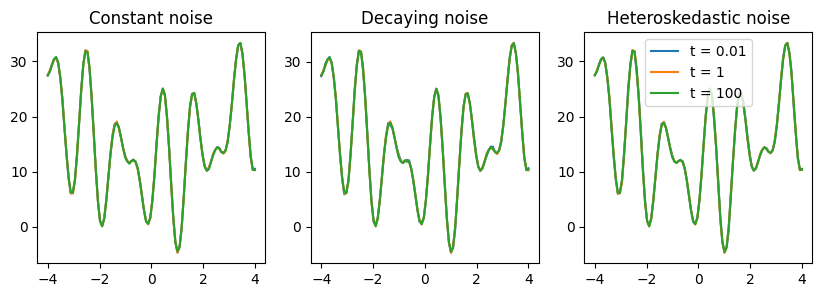

In [39]:
#@title example: grid measurements with different acqusition time

x = np.linspace(-4,4, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]

noise_heter_model = make_heteroskedastic_noise_model(model, (-4, 4))

sim_const = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_constant,
    rng=123,
)

sim_decay = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_decay_floor,
    rng=123,
)

sim_heterosk = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_heter_model,
    rng=123,
)

fig, ax = plt.subplots(1, 3, figsize=(10,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax[0].plot(coords[:,0], sim_const.measure(coords), label = f't = {d}')
  ax[1].plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')
  ax[2].plot(coords[:,0], sim_heterosk.measure(coords), label = f't = {d}')

ax[0].set_title('Constant noise')
ax[1].set_title('Decaying noise')
ax[2].set_title('Heteroskedastic noise')
ax[2].legend()

In [40]:
#@title example: surrogate modeling

#homoskedatic noise model: [noise_constant, noise_decay_floor]
#ground truth models: [unimodal, double_well, multimodal, broad_narrow]


#If we select the heteroskedastic noise model, we first need to construct it. For the homoskedastic cases, the models are already defined.
noise_heter_model = make_heteroskedastic_noise_model(double_well, xlim=(-4, 4)) #please define the x range

meas_sim = MeasurementSimulator(
    ground_truth_model=double_well,
    noise_model=noise_heter_model,
    rng=123,
)

In [41]:

#define x_grid on the explored interval

x_grid = np.linspace(-4, 4, 500)

# For this example, select 4 random locations in the range (-4, 4)
x = np.random.random(7) * 8 - 4

# Set acquisition time (t = 3) for all locations
t = np.ones(len(x)) * 1

# Form the coordinate array: [[x1, t1], [x2, t2], ...]
coords = np.column_stack([x, t])

#make "measurements"
y = meas_sim.measure(coords)

#surrogate modeling
mean, std = gp_predict(x, y, x_grid, training_iter=100, lr=0.1)

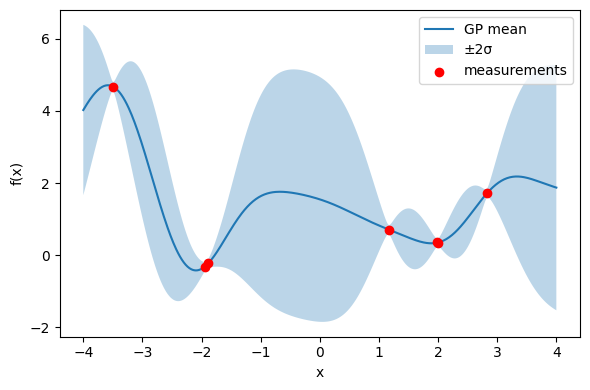

In [42]:
plt.figure(figsize=(6, 4))

# GP mean
plt.plot(x_grid, mean, label="GP mean")

# uncertainty band
plt.fill_between(
  x_grid,
  mean - 2 * std,
  mean + 2 * std,
  alpha=0.3,
  label="±2σ"
)

# training points
plt.scatter(x, y, color="red", zorder=3, label="measurements")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

For simplicity, we treat time as the cost function. The cost of a single measurement is therefore equal to its acquisition time. In addition, we introduce a travel cost, which accounts for moving between measurement locations and is assumed to be proportional to the distance between them.

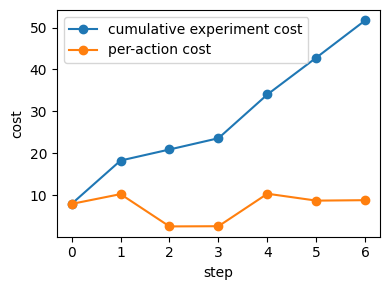

In [43]:
#@title total experiment cost

# initial position
x0 = 0

# displacement between consecutive points (including first move from x0)
dx = x - np.append(x0, x[:-1])

# cost of each action = travel cost + acquisition time
action_costs = travel_cost(dx) + t

# visualize costs
fig = plt.figure(figsize=(4,3))
plt.plot(np.cumsum(action_costs), 'o-', label='cumulative experiment cost')
plt.plot(action_costs, 'o-', label='per-action cost')

plt.xlabel('step')
plt.ylabel('cost')
plt.legend()
plt.tight_layout()




---


## Lets go!
---



Design a strategy that selects where to measure, in what order, and for how long, using the provided simulator and a fixed total budget. The objective is to explore or optimize the underlying function as efficiently as possible under noisy measurements and movement cost.

In [44]:
#your code


In [45]:
def choose_local_time(std_x, curv_x, t_candidates):
    """
    Pick measurement time based on local uncertainty and curvature.

    Rules:
    - low uncertainty + low curvature -> short time
    - medium -> medium time
    - high uncertainty or high curvature -> longer time
    """
    score = 0.7 * std_x + 0.3 * curv_x

    t_candidates = np.asarray(sorted(t_candidates), dtype=float)

    if score < 0.35:
        return t_candidates[0]
    elif score < 0.7:
        return t_candidates[min(1, len(t_candidates)-1)]
    elif score < 1.1:
        return t_candidates[min(2, len(t_candidates)-1)]
    else:
        return t_candidates[-1]

In [49]:
def run_campaign_design(
    meas_sim,
    B=100,
    xlim=(-4, 4),
    x0=0.0,
    n_scout=7,
    scout_t=0.5,
    n_regions=8,
    refine_points_per_region=3,
    min_points_per_region=2,
    candidate_t=(0.25, 0.5, 1.0, 2.0, 4.0, 6.0),
    gp_training_iter=100,
    gp_lr=0.1,
    w_travel=1.8,      # MOST important
    w_unc=0.8,
    w_curv=0.5,
    region_budget_fraction=0.75,
    revisit_tol=1e-3,
):
    """
    Campaign-style adaptive experimental design.

    Returns a history dict with measurements and GP outputs.
    """

    xmin, xmax = xlim
    x_dense = np.linspace(xmin, xmax, 500)

    x_obs = []
    t_obs = []
    y_obs = []
    action_costs = []

    B_rem = float(B)
    x_curr = float(x0)

    # -------------------------
    # Phase 1: global scouting
    # -------------------------
    scout_x = np.linspace(xmin, xmax, n_scout)

    for x_next in scout_x:
        move = travel_cost(x_next - x_curr)
        cost = move + scout_t
        if cost > B_rem:
            break

        y_next = meas_sim.measure(np.array([[x_next, scout_t]]))[0]

        x_obs.append(float(x_next))
        t_obs.append(float(scout_t))
        y_obs.append(float(y_next))
        action_costs.append(float(cost))

        B_rem -= cost
        x_curr = float(x_next)

    if len(x_obs) < 2:
        return {
            "x": np.array(x_obs),
            "t": np.array(t_obs),
            "y": np.array(y_obs),
            "costs": np.array(action_costs),
            "remaining_budget": B_rem,
            "gp_grid": None,
            "gp_mean": None,
            "gp_std": None,
            "region_info": None,
        }

    # ------------------------------------------
    # Main campaign loop: region plan + refine
    # ------------------------------------------
    while True:
        # Fit GP on current data
        gp_mean, gp_std = gp_predict(
            np.array(x_obs),
            np.array(y_obs),
            x_dense,
            training_iter=gp_training_iter,
            lr=gp_lr,
        )

        # Curvature estimate from GP mean
        gp_curv = np.abs(np.gradient(np.gradient(gp_mean, x_dense), x_dense))

        # Normalize region features
        std_scale = np.percentile(gp_std, 95) + 1e-8
        curv_scale = np.percentile(gp_curv, 95) + 1e-8

        gp_std_n = gp_std / std_scale
        gp_curv_n = gp_curv / curv_scale

        # Build regions
        region_edges = np.linspace(xmin, xmax, n_regions + 1)
        regions = []
        for i in range(n_regions):
            a, b = region_edges[i], region_edges[i + 1]
            center = 0.5 * (a + b)
            mask = (x_dense >= a) & (x_dense <= b)

            if np.sum(mask) == 0:
                continue

            mean_unc = float(np.mean(gp_std_n[mask]))
            mean_curv = float(np.mean(gp_curv_n[mask]))

            # cheaper-to-reach is most important
            dist = abs(center - x_curr)
            move = travel_cost(center - x_curr)

            # higher travel cost should reduce score strongly
            # use inverse-style reachability
            reachability = 1.0 / (1.0 + move)

            region_score = (
                w_travel * reachability +
                w_unc * mean_unc +
                w_curv * mean_curv
            )

            regions.append({
                "idx": i,
                "a": float(a),
                "b": float(b),
                "center": float(center),
                "mean_unc": mean_unc,
                "mean_curv": mean_curv,
                "move_from_current": float(move),
                "reachability": float(reachability),
                "score": float(region_score),
            })

        if len(regions) == 0:
            break

        # Sort regions by campaign priority
        regions = sorted(regions, key=lambda r: r["score"], reverse=True)

        # Allocate only part of remaining budget for current campaign round
        round_budget = region_budget_fraction * B_rem
        if round_budget <= min(candidate_t):
            break

        total_region_score = sum(r["score"] for r in regions) + 1e-8

        # Predict budget allocation to each region
        for r in regions:
            r["allocated_budget"] = round_budget * (r["score"] / total_region_score)

        # Visit regions in priority order, but re-fit/update after each region
        visited_any_region = False
        region_info_this_round = []

        for r in regions:
            if B_rem <= min(candidate_t):
                break

            a, b = r["a"], r["b"]
            center = r["center"]

            # If it costs too much just to get there and do anything, skip
            min_region_entry_cost = travel_cost(center - x_curr) + min(candidate_t)
            if min_region_entry_cost > B_rem:
                continue

            region_budget = min(r["allocated_budget"], B_rem)
            region_spent = 0.0

            # Choose local points in this region
            local_candidates = np.linspace(a, b, refine_points_per_region + 2)[1:-1]

            # Reorder local points to avoid long jumps:
            # start from the nearest local point to current position
            local_candidates = sorted(local_candidates, key=lambda xx: abs(xx - x_curr))

            local_taken = 0

            while local_taken < refine_points_per_region:
                # Refit GP dynamically before each local action
                gp_mean, gp_std = gp_predict(
                    np.array(x_obs),
                    np.array(y_obs),
                    x_dense,
                    training_iter=gp_training_iter,
                    lr=gp_lr,
                )
                gp_curv = np.abs(np.gradient(np.gradient(gp_mean, x_dense), x_dense))

                std_scale = np.percentile(gp_std, 95) + 1e-8
                curv_scale = np.percentile(gp_curv, 95) + 1e-8
                gp_std_n = gp_std / std_scale
                gp_curv_n = gp_curv / curv_scale

                # Filter out exact repeats
                valid_local = []
                for xx in local_candidates:
                    if len(x_obs) == 0 or np.min(np.abs(np.array(x_obs) - xx)) > revisit_tol:
                        valid_local.append(xx)

                if len(valid_local) == 0:
                    break

                # Choose next local point with travel-aware preference
                best_local = None
                best_local_score = -np.inf

                for xx in valid_local:
                    std_x = float(np.interp(xx, x_dense, gp_std_n))
                    curv_x = float(np.interp(xx, x_dense, gp_curv_n))
                    move_x = travel_cost(xx - x_curr)

                    # local travel still matters a lot
                    local_score = (
                        1.8 / (1.0 + move_x) +
                        0.8 * std_x +
                        0.5 * curv_x
                    )

                    if local_score > best_local_score:
                        best_local_score = local_score
                        best_local = xx

                x_next = float(best_local)

                # pick time adaptively
                std_x = float(np.interp(x_next, x_dense, gp_std_n))
                curv_x = float(np.interp(x_next, x_dense, gp_curv_n))
                t_next = float(choose_local_time(std_x, curv_x, candidate_t))

                move = travel_cost(x_next - x_curr)
                total_cost = move + t_next

                # respect both region allocation and global budget
                if total_cost > B_rem or (region_spent + total_cost) > region_budget:
                    break

                y_next = meas_sim.measure(np.array([[x_next, t_next]]))[0]

                x_obs.append(x_next)
                t_obs.append(t_next)
                y_obs.append(float(y_next))
                action_costs.append(float(total_cost))

                B_rem -= total_cost
                region_spent += total_cost
                x_curr = x_next
                local_taken += 1
                visited_any_region = True

                # remove point from local candidate list
                local_candidates = [xx for xx in local_candidates if abs(xx - x_next) > revisit_tol]

                if B_rem <= min(candidate_t):
                    break

            region_info_this_round.append({
                **r,
                "spent": region_spent,
                "points_taken": local_taken,
            })

        if not visited_any_region:
            break

        # If we cannot afford even the cheapest future action, stop
        if B_rem < min(candidate_t):
            break

    # Final GP
    gp_mean, gp_std = gp_predict(
        np.array(x_obs),
        np.array(y_obs),
        x_dense,
        training_iter=gp_training_iter,
        lr=gp_lr,
    )

    return {
        "x": np.array(x_obs),
        "t": np.array(t_obs),
        "y": np.array(y_obs),
        "costs": np.array(action_costs),
        "remaining_budget": B_rem,
        "gp_grid": x_dense,
        "gp_mean": gp_mean,
        "gp_std": gp_std,
    }

In [47]:
def plot_campaign_results(history, ground_truth_model, xlim=(-4, 4), x0=0.0):
    x_plot = np.linspace(xlim[0], xlim[1], 500)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    # Ground truth + GP
    ax[0].plot(x_plot, ground_truth_model(x_plot), label="ground truth", linewidth=2)
    ax[0].plot(history["gp_grid"], history["gp_mean"], label="GP mean")
    ax[0].fill_between(
        history["gp_grid"],
        history["gp_mean"] - 2 * history["gp_std"],
        history["gp_mean"] + 2 * history["gp_std"],
        alpha=0.3,
        label="±2σ"
    )
    sc = ax[0].scatter(history["x"], history["y"], c=history["t"], s=55, zorder=3)
    ax[0].set_title("Function recovery")
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("f(x)")
    ax[0].legend()
    cbar = plt.colorbar(sc, ax=ax[0])
    cbar.set_label("measurement time t")

    # Measurement order in x
    ax[1].plot(np.arange(len(history["x"])), history["x"], "o-")
    ax[1].axhline(x0, linestyle="--", alpha=0.5)
    ax[1].set_title("Measurement order in space")
    ax[1].set_xlabel("step")
    ax[1].set_ylabel("x")

    # Budget
    cumulative = np.cumsum(history["costs"])
    ax[2].plot(np.arange(1, len(cumulative)+1), cumulative, "o-", label="cumulative cost")
    ax[2].bar(np.arange(1, len(history["costs"])+1), history["costs"], alpha=0.4, label="step cost")
    ax[2].set_title("Budget use")
    ax[2].set_xlabel("step")
    ax[2].set_ylabel("cost")
    ax[2].legend()

    plt.tight_layout()
    plt.show()

    print("Measurement plan:")
    prev = x0
    for i, (x_i, t_i, c_i) in enumerate(zip(history["x"], history["t"], history["costs"]), start=1):
        move_i = travel_cost(x_i - prev)
        print(f"step {i:2d}: x={x_i: .3f}, t={t_i: .2f}, move={move_i: .2f}, total={c_i: .2f}")
        prev = x_i

    print(f"\nRemaining budget: {history['remaining_budget']:.2f}")

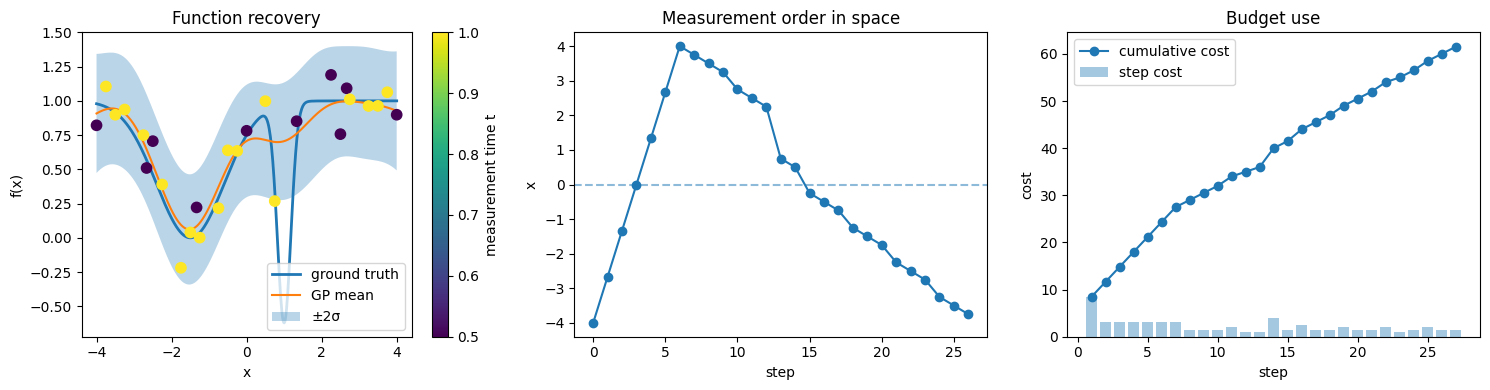

Measurement plan:
step  1: x=-4.000, t= 0.50, move= 8.00, total= 8.50
step  2: x=-2.667, t= 0.50, move= 2.67, total= 3.17
step  3: x=-1.333, t= 0.50, move= 2.67, total= 3.17
step  4: x= 0.000, t= 0.50, move= 2.67, total= 3.17
step  5: x= 1.333, t= 0.50, move= 2.67, total= 3.17
step  6: x= 2.667, t= 0.50, move= 2.67, total= 3.17
step  7: x= 4.000, t= 0.50, move= 2.67, total= 3.17
step  8: x= 3.750, t= 1.00, move= 0.50, total= 1.50
step  9: x= 3.500, t= 1.00, move= 0.50, total= 1.50
step 10: x= 3.250, t= 1.00, move= 0.50, total= 1.50
step 11: x= 2.750, t= 1.00, move= 1.00, total= 2.00
step 12: x= 2.500, t= 0.50, move= 0.50, total= 1.00
step 13: x= 2.250, t= 0.50, move= 0.50, total= 1.00
step 14: x= 0.750, t= 1.00, move= 3.00, total= 4.00
step 15: x= 0.500, t= 1.00, move= 0.50, total= 1.50
step 16: x=-0.250, t= 1.00, move= 1.50, total= 2.50
step 17: x=-0.500, t= 1.00, move= 0.50, total= 1.50
step 18: x=-0.750, t= 1.00, move= 0.50, total= 1.50
step 19: x=-1.250, t= 1.00, move= 1.00, total=

In [50]:
B = 100 #your budget

meas_sim = MeasurementSimulator(
    ground_truth_model=broad_narrow, #choose gt function - broad + narrow
    noise_model=noise_decay_floor,  #choose noise model - decaying noise
    rng=123, # will change if I want different noise - going to use 123, 456, and 789
)

history = run_campaign_design(
    meas_sim=meas_sim,
    B=B,
    xlim=(-4, 4),
    x0=0.0,
    n_scout=7,
    scout_t=0.5,
    n_regions=8,
    refine_points_per_region=3,
    min_points_per_region=2, # checks region for 2 points that budget allows before continuing to use budget in that region
    candidate_t=(0.25, 0.5, 1.0, 2.0, 4.0, 6.0),
    gp_training_iter=100,
    gp_lr=0.1,
    w_travel=1.8,
    w_unc=0.8,
    w_curv=0.8,
)

plot_campaign_results(history, broad_narrow, xlim=(-4, 4), x0=0.0)

In [51]:
def plot_cost_trace(history):
    """
    Plot cumulative experiment cost and per-action cost vs step.
    Expects history to contain key 'costs'.
    """
    costs = np.asarray(history["costs"], dtype=float)
    steps = np.arange(len(costs))
    cumulative = np.cumsum(costs)

    plt.figure(figsize=(6, 4))
    plt.plot(steps, cumulative, 'o-', label='cumulative experiment cost')
    plt.plot(steps, costs, 'o-', label='per-action cost')

    plt.xlabel('step')
    plt.ylabel('cost')
    plt.legend()
    plt.tight_layout()
    plt.show()

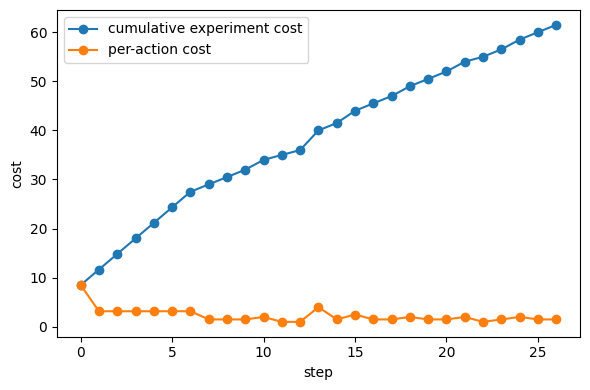

In [52]:
plot_cost_trace(history)